In [40]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [41]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "outputs" / "APL_Logistics_ml_ready.csv"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Project root: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project
Data path: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs\APL_Logistics_ml_ready.csv
Model directory: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\models
Output directory: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs


In [42]:
df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (180519, 37)


,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Category Name,Customer City,Customer Country,Customer Segment,Customer State,...,Product Name,Product Price,Shipping Mode,discount_amount_per_unit,sales_per_quantity,profit_per_quantity,price_discount_interaction,scheduled_days_bucket,geo_market_region,Late_delivery_risk
0,DEBIT,4,159.69,472.45,9,Cardio Equipment,Brownsville,EE. UU.,Consumer,TX,...,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,5.500,99.99,31.938,5.9994,4,Pacific Asia | South Asia,1
1,DEBIT,4,48.71,167.96,29,Shop By Sport,Littleton,EE. UU.,Consumer,CO,...,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,6.398,39.99,9.742,6.3984,4,LATAM | Central America,0
2,DEBIT,4,87.36,181.99,48,Water Sports,Littleton,EE. UU.,Consumer,CO,...,Pelican Sunstream 100 Kayak,199.99,Standard Class,18.000,199.99,87.360,17.9991,4,LATAM | Central America,0
3,DEBIT,4,-41.89,175.99,48,Water Sports,Littleton,EE. UU.,Consumer,CO,...,Pelican Sunstream 100 Kayak,199.99,Standard Class,24.000,199.99,-41.890,23.9988,4,USCA | East of USA,1
4,DEBIT,4,10.00,40.00,24,Women's Apparel,Littleton,EE. UU.,Consumer,CO,...,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,10.000,50.00,10.000,10.0000,4,USCA | East of USA,1


In [43]:
TARGET = "Late_delivery_risk"

y = df[TARGET].astype(int)

print("Target distribution:")
print(y.value_counts())

print("\nTarget percenatge:")
print(y.value_counts(normalize=True).round(4))

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Target percenatge:
Late_delivery_risk
1    0.5483
0    0.4517
Name: proportion, dtype: float64


In [44]:
TIMING_SENSITIVE_COLUMNS = [
    "Order Profit Per Order",
    "profit_per_quantity",
    "Benefit per Order"
]

x = df.drop(
    columns=[TARGET],
    errors="ignore"
).copy()

x = x.drop(
    columns=TIMING_SENSITIVE_COLUMNS,
    errors="ignore"
)

print("Festure shape:",x.shape)

Festure shape: (180519, 34)


In [45]:
LEAKAGE_COLUMNS = [
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Delivery Status",
    "Order Status",
    "Delay_Gap"
]

leakage_present = [
    col for col in LEAKAGE_COLUMNS
    if col in x.columns
]

print("Leakage columns present:")
print(leakage_present)

Leakage columns present:
[]


In [46]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", x_train.shape)
print("Testing:",x_test.shape)

Training: (144415, 34)
Testing: (36104, 34)


In [47]:
logistics_model_path = (
    MODEL_DIR / "logistic_regression_pipeline.joblib"
)

logistics_model = joblib.load(
    logistics_model_path
)

print("Logistic Regression model loaded.")

Logistic Regression model loaded.


In [48]:
lightgbm_model_path = (
    MODEL_DIR / "lightgbm_delay_risk_model.joblib"
)

lightgbm_model = joblib.load(
    lightgbm_model_path
)

print("LightGBM model loaded.")

LightGBM model loaded.


In [49]:
categorical_features = x_train.select_dtypes(
    include = ["object"]
).columns.tolist()

x_test_lgb = x_test.copy()

for col in categorical_features:
    x_test_lgb[col] = x_test_lgb[col].astype("category")

print("LightGBM test data prepared.")

LightGBM test data prepared.


C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\3794330511.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_train.select_dtypes(


In [50]:
x_train_lgb = x_train.copy()

for col in categorical_features:
    x_train_lgb[col] = x_train_lgb[col].astype("category")
    
    x_test_lgb[col] = x_test_lgb[col].astype(
        pd.api.types.CategoricalDtype(
            categories=x_train_lgb[col].cat.categories
        )
    )

print("Categorical levels aligned.")

Categorical levels aligned.


C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\3173281732.py:6: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x_test_lgb[col] = x_test_lgb[col].astype(
C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\3173281732.py:6: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x_test_lgb[col] = x_test_lgb[col].astype(


In [51]:
logistic_pred = logistics_model.predict(x_test)

logistic_proba = logistics_model.predict_proba(
    x_test
)[:,1]

print("Logistic predictions generated")

Logistic predictions generated


In [52]:
# Original columns in our evaluation dataframe
evaluation_columns = x_test.columns.tolist()

# Features stored inside the trained LightGBM model
model_features = lightgbm_model.feature_name_

print("Model features:", len(model_features))
print("Evaluation features:", len(evaluation_columns))

print("\nModel feature names:")
print(model_features)

Model features: 33
Evaluation features: 34

Model feature names:
['Type', 'Days_for_shipment_(scheduled)', 'Sales_per_customer', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Segment', 'Customer_State', 'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market', 'Order_City', 'Order_Country', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Product_Price', 'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Sales', 'Order_Item_Total', 'Order_Region', 'Order_State', 'Product_Name', 'Product_Price', 'Shipping_Mode', 'discount_amount_per_unit', 'sales_per_quantity', 'price_discount_interaction', 'scheduled_days_bucket', 'geo_market_region']


In [53]:
# Map LightGBM's internal feature name -> original dataframe column
feature_mapping = {}

for col in evaluation_columns:
    lightgbm_name = col.replace(" ", "_")
    feature_mapping[lightgbm_name] = col

print("Feature mapping created.")

Feature mapping created.


In [54]:
matched_columns = []

for model_feature in model_features:
    
    if model_feature in feature_mapping:
        matched_columns.append(
            feature_mapping[model_feature]
        )

print("Matched features:", len(matched_columns))

print("\nMatched columns:")
print(matched_columns)

Matched features: 33

Matched columns:
['Type', 'Days for shipment (scheduled)', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Shipping Mode', 'discount_amount_per_unit', 'sales_per_quantity', 'price_discount_interaction', 'scheduled_days_bucket', 'geo_market_region']


In [55]:
missing_model_features = [
    feature
    for feature in model_features
    if feature not in feature_mapping
]

print("Missing model features:")
print(missing_model_features)

Missing model features:
[]


In [56]:
x_test_lgb = x_test[
    matched_columns
].copy()

print("Final LightGBM test shape:")
print(x_test_lgb.shape)

Final LightGBM test shape:
(36104, 33)


In [57]:
categorical_features = x_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features_lgb = [
    col
    for col in matched_columns
    if col in categorical_features
]

print("Categorical features:")
print(categorical_features_lgb)

Categorical features:
['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Product Name', 'Shipping Mode', 'geo_market_region']


C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\3881523686.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x_train.select_dtypes(


In [58]:
for col in categorical_features_lgb:
    
    train_categories = (
        x_train[col]
        .astype("category")
        .cat.categories
    )
    
    x_test_lgb[col] = pd.Categorical(
        x_test_lgb[col],
        categories=train_categories
    )

print("Categorical columns prepared successfully.")

C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\427193282.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x_test_lgb[col] = pd.Categorical(


Categorical columns prepared successfully.


C:\Users\ganesh\AppData\Local\Temp\ipykernel_21684\427193282.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  x_test_lgb[col] = pd.Categorical(


In [59]:
print("Final test data:")
print("Rows:", x_test_lgb.shape[0])
print("Columns:", x_test_lgb.shape[1])

print("\nExpected model features:", len(model_features))

print("\nColumn names:")
print(x_test_lgb.columns.tolist())

Final test data:
Rows: 36104
Columns: 33

Expected model features: 33

Column names:
['Type', 'Days for shipment (scheduled)', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Shipping Mode', 'discount_amount_per_unit', 'sales_per_quantity', 'price_discount_interaction', 'scheduled_days_bucket', 'geo_market_region']


In [60]:
lightgbm_pred = lightgbm_model.predict(
    x_test_lgb
)

lightgbm_proba = lightgbm_model.predict_proba(
    x_test_lgb
)[:, 1]

print("LightGBM predictions generated.")

LightGBM predictions generated.


In [61]:
evaluation_results = []

models = {
    "Logistic Regression": (
        logistic_pred,
        logistic_proba
    ),
    "LightGBM": (
        lightgbm_pred,
        lightgbm_proba
    )
}

for model_name, (predictions, probabilities) in models.items():
    
    evaluation_results.append({
        "Model":model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "Average Precision": average_precision_score(
            y_test,
            probabilities
        )
    })
    
evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,0.707512,0.808442,0.611437,0.696272,0.775385,0.832006
1,LightGBM,0.773626,0.839913,0.725399,0.778467,0.860411,0.895573


In [62]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Average Precision"
]

evaluation_df[metric_columns] = (
    evaluation_df[metric_columns].round(4)
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,0.7075,0.8084,0.6114,0.6963,0.7754,0.8320
1,LightGBM,0.7736,0.8399,0.7254,0.7785,0.8604,0.8956


In [63]:
evaluation_path = (
    OUTPUT_DIR / "model_evaluation.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False
)

print("Saved:", evaluation_path)

Saved: c:\Users\ganesh\Desktop\All Projects\Build Logistic Analysis Project\outputs\model_evaluation.csv


In [64]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

print(logistic_cm)

[[13440  2868]
 [ 7692 12104]]


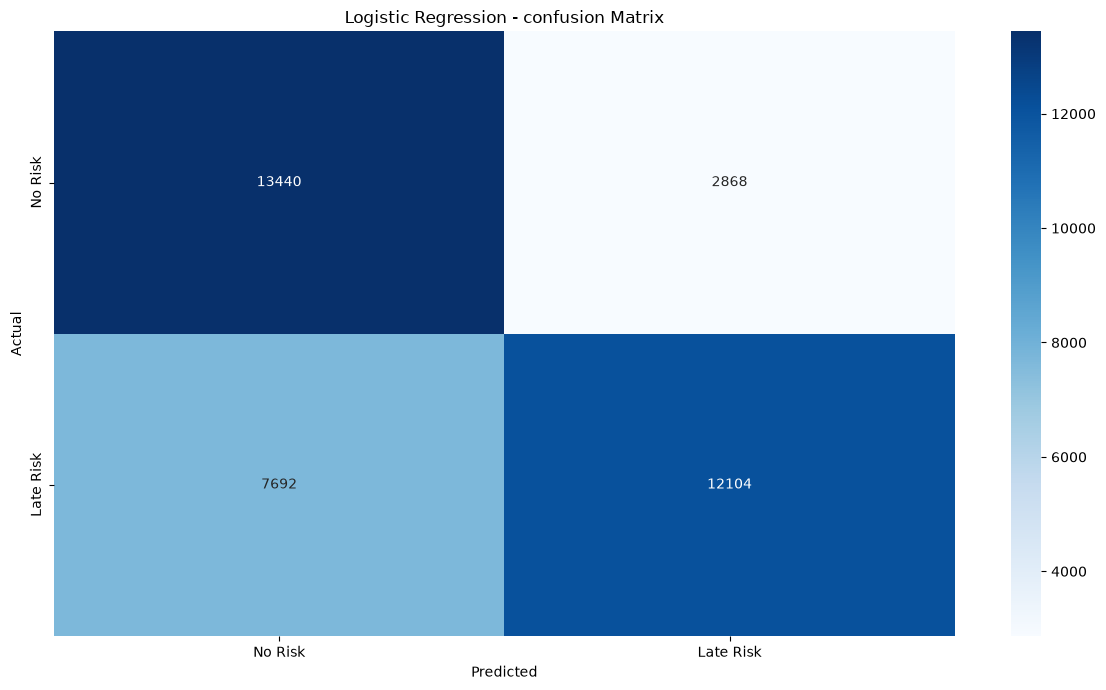

In [65]:
plt.figure(figsize=(12,7))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Risk", "Late Risk"],
    yticklabels=["No Risk", "Late Risk"]
)

plt.title("Logistic Regression - confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [66]:
lightgbm_cm = confusion_matrix(
    y_test,
    lightgbm_pred
)

print(lightgbm_cm)

[[13571  2737]
 [ 5436 14360]]


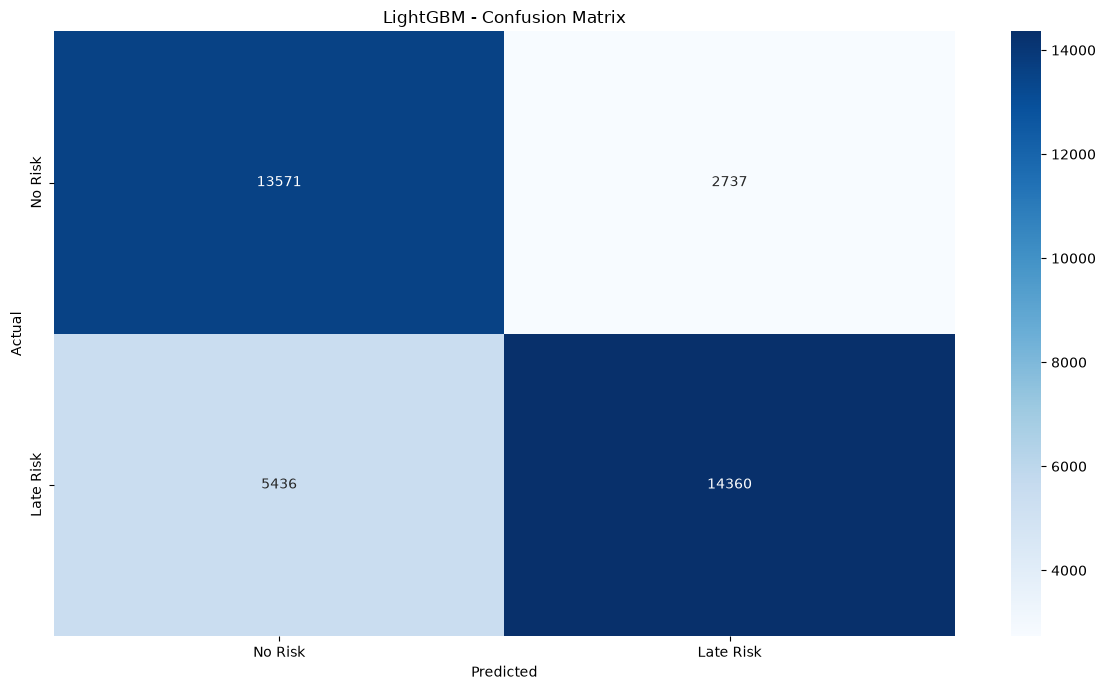

In [67]:
plt.figure(figsize=(12,7))

sns.heatmap(
    lightgbm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Risk", "Late Risk"],
    yticklabels=["No Risk", "Late Risk"]
)

plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [68]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names= [
            "No Late Risk",
            "Late Risk"
        ]
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

No Late Risk       0.64      0.82      0.72     16308
   Late Risk       0.81      0.61      0.70     19796

    accuracy                           0.71     36104
   macro avg       0.72      0.72      0.71     36104
weighted avg       0.73      0.71      0.71     36104



In [69]:
print("LIGHTGBM")
print("=" * 50)

print(
    classification_report(
        y_test,
        lightgbm_pred,
        target_names= [
            "No Late Risk",
            "Late Risk"
        ]
    )
)

LIGHTGBM
              precision    recall  f1-score   support

No Late Risk       0.71      0.83      0.77     16308
   Late Risk       0.84      0.73      0.78     19796

    accuracy                           0.77     36104
   macro avg       0.78      0.78      0.77     36104
weighted avg       0.78      0.77      0.77     36104



In [70]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_proba
)

lightgbm_fpr, lightgbm_tpr, _ = roc_curve(
    y_test,
    lightgbm_proba
)

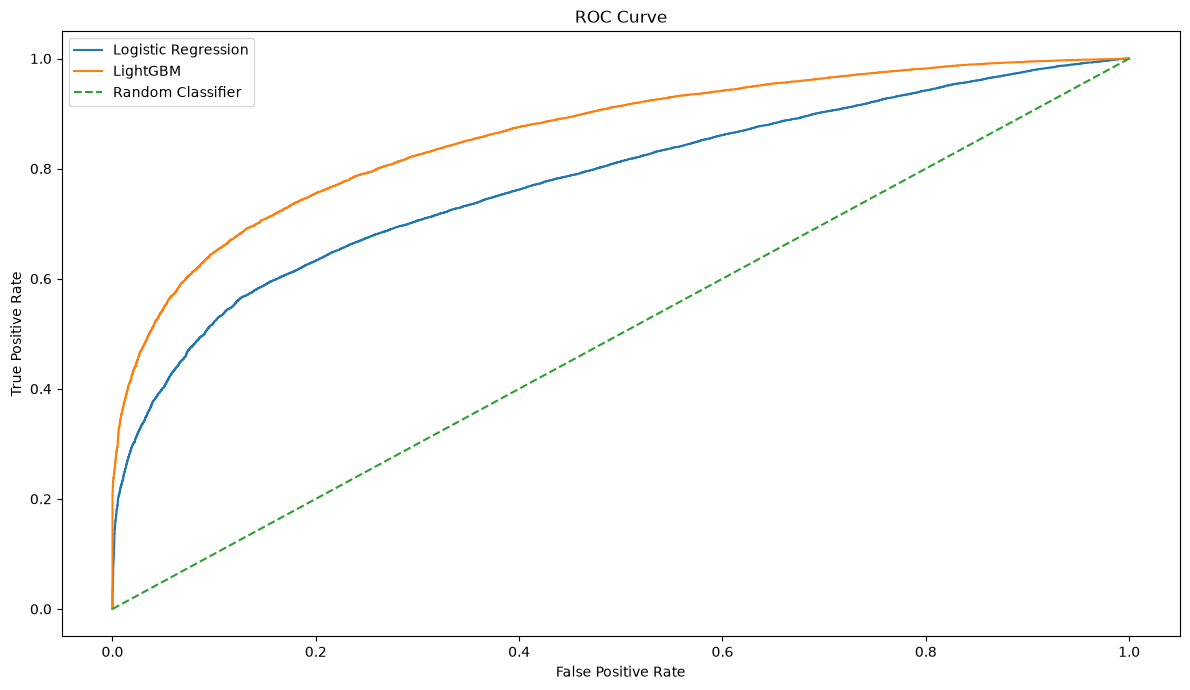

In [71]:
plt.figure(figsize=(12,7))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label = "Logistic Regression"
)

plt.plot(
    lightgbm_fpr,
    lightgbm_tpr,
    label = "LightGBM"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle= "--",
    label = "Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
logistic_precision_curve, logistic_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        logistic_proba
    )
)

lightgbm_precision_curve, lightgbm_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        lightgbm_proba
    )
)

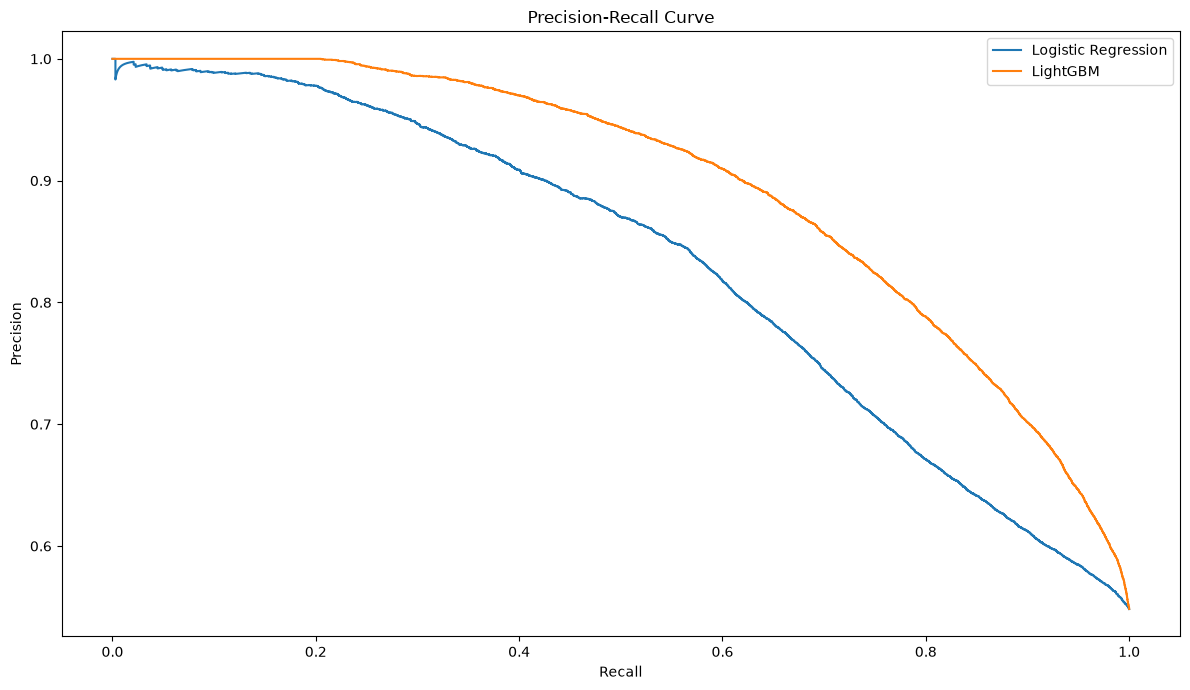

In [73]:
plt.figure(figsize=(12,7))

plt.plot(
    logistic_recall_curve,
    logistic_precision_curve,
    label = "Logistic Regression"
)

plt.plot(
    lightgbm_recall_curve,
    lightgbm_precision_curve,
    label = "LightGBM"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

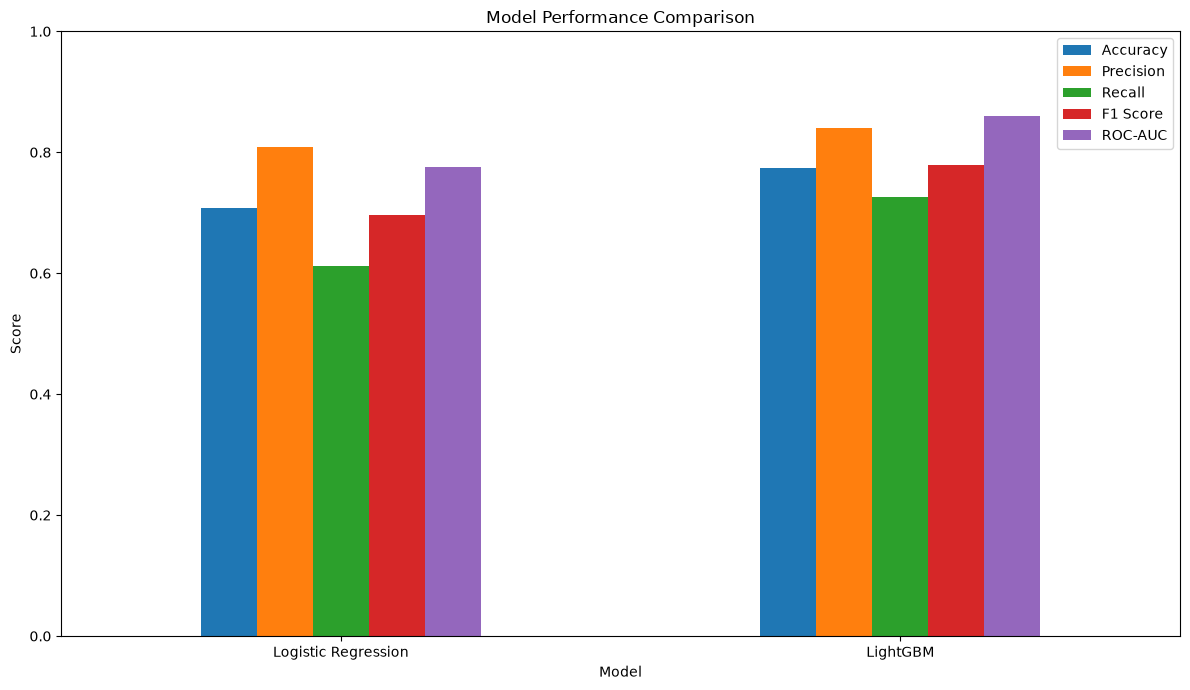

In [74]:
plot_df = evaluation_df.set_index("Model")

plot_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].plot(
    kind = "bar",
    figsize=(12,7)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
logistic_fn = (
    (y_test == 1) &
    (logistic_pred == 0)
).sum()

lightgbm_fn = (
    (y_test == 1) &
    (lightgbm_pred == 0)
).sum()

print("False Negatives")
print("-" * 30)
print(
    "Logistic Regression:",
    logistic_fn
)
print(
    "LightGBM:",
    lightgbm_fn
)

False Negatives
------------------------------
Logistic Regression: 7692
LightGBM: 5436
